In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [3]:
TRAIN_DIR = "‪F:/skin_app/train"
TEST_DIR  = "F:/skin_app/test"

IMG_SIZE = 64
BATCH_SIZE = 32


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# =========================
# SETTINGS
# =========================

IMG_SIZE = 224
BATCH_SIZE = 32

# Dataset Paths
TRAIN_DIR = r"F:\skin_app\train"
TEST_DIR = r"F:\skin_app\test"

# =========================
# CHECK FOLDERS
# =========================

print("Train Folder:", os.listdir(TRAIN_DIR))
print("Test Folder:", os.listdir(TEST_DIR))

# =========================
# IMAGE GENERATORS
# =========================

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True
)

test_gen = ImageDataGenerator(
    rescale=1./255
)

# =========================
# LOAD TRAIN DATA
# =========================

train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

# =========================
# LOAD TEST DATA
# =========================

test_data = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

# =========================
# SUCCESS MESSAGE
# =========================

print("Data Loaded Successfully ✅")
print("Classes:", train_data.class_indices)

Train Folder: ['Acne', 'Benign_tumors', 'Infestations_Bites', 'Moles', 'Sun_Sunlight_Damage', 'Unknown_Normal']
Test Folder: ['Acne', 'Benign_tumors', 'Infestations_Bites', 'Moles', 'Sun_Sunlight_Damage', 'Unknown_Normal']
Found 6313 images belonging to 6 classes.
Found 6313 images belonging to 6 classes.
Data Loaded Successfully ✅
Classes: {'Acne': 0, 'Benign_tumors': 1, 'Infestations_Bites': 2, 'Moles': 3, 'Sun_Sunlight_Damage': 4, 'Unknown_Normal': 5}


In [5]:
print(train_data.class_indices)


{'Acne': 0, 'Benign_tumors': 1, 'Infestations_Bites': 2, 'Moles': 3, 'Sun_Sunlight_Damage': 4, 'Unknown_Normal': 5}


In [6]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')  # 🔥 auto classes
])


C:\Users\786\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [8]:
print("Total classes:", train_data.num_classes)
print(train_data.class_indices)


Total classes: 6
{'Acne': 0, 'Benign_tumors': 1, 'Infestations_Bites': 2, 'Moles': 3, 'Sun_Sunlight_Damage': 4, 'Unknown_Normal': 5}


In [9]:
model.save("skin_disease_multiclass_model.h5")


In [10]:
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import load_img

# ✅ Dataset path (TRAIN folder tak)
dataset_path = "F:/skin_app/train"

data = []

# 🔁 Loop through each disease folder
for disease in os.listdir(dataset_path):
    disease_path = os.path.join(dataset_path, disease)

    # skip if not directory
    if not os.path.isdir(disease_path):
        continue

    # 🔁 Loop through images
    for img in os.listdir(disease_path):
        img_path = os.path.join(disease_path, img)

        # only image files
        if img.lower().endswith(('.png', '.jpg', '.jpeg')):
            image = load_img(img_path)
            w, h = image.size

            data.append([img_path, disease, w, h])

# 📊 Create DataFrame
df = pd.DataFrame(data, columns=["image_path", "label", "width", "height"])

print(df.head())
print("\nTotal Images:", len(df))
print("\nClasses:\n", df['label'].value_counts())


                                        image_path label  width  height
0         F:/skin_app/train\Acne\07Acne081101.jpeg  Acne    720     472
1          F:/skin_app/train\Acne\07Acne081101.jpg  Acne    720     472
2  F:/skin_app/train\Acne\07Acne0811011 - Copy.jpg  Acne    720     472
3         F:/skin_app/train\Acne\07Acne0811011.jpg  Acne    720     472
4    F:/skin_app/train\Acne\07AcnePittedScars.jpeg  Acne    720     472

Total Images: 6313

Classes:
 label
Acne                   2425
Unknown_Normal         1651
Benign_tumors          1083
Infestations_Bites      483
Moles                   361
Sun_Sunlight_Damage     310
Name: count, dtype: int64


In [11]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)

Epoch 1/5
198/198 ━━━━━━━━━━━━━━━━━━━━ 1122s 6s/step - accuracy: 0.5364 - loss: 1.3621 - val_accuracy: 0.6311 - val_loss: 1.1054
Epoch 2/5
198/198 ━━━━━━━━━━━━━━━━━━━━ 1103s 6s/step - accuracy: 0.6198 - loss: 1.1190 - val_accuracy: 0.6604 - val_loss: 1.0106
Epoch 3/5
198/198 ━━━━━━━━━━━━━━━━━━━━ 866s 4s/step - accuracy: 0.6339 - loss: 1.0837 - val_accuracy: 0.6841 - val_loss: 0.9394
Epoch 4/5
198/198 ━━━━━━━━━━━━━━━━━━━━ 728s 4s/step - accuracy: 0.6642 - loss: 0.9888 - val_accuracy: 0.6655 - val_loss: 0.9445
Epoch 5/5
198/198 ━━━━━━━━━━━━━━━━━━━━ 713s 4s/step - accuracy: 0.6604 - loss: 0.9731 - val_accuracy: 0.7093 - val_loss: 0.8208


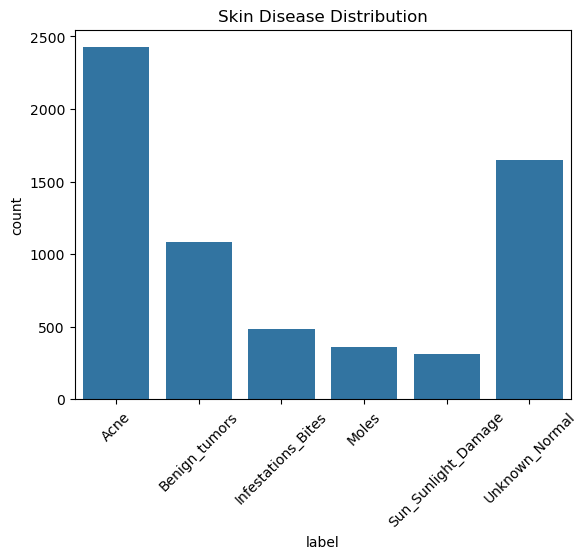

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt  # Ye bhi zaroori hai agar aap plot show karna chahte hain
sns.countplot(x="label", data=df)
plt.title("Skin Disease Distribution")
plt.xticks(rotation=45)
plt.show()

In [13]:
encoder = LabelEncoder()
df["encoded_label"] = encoder.fit_transform(df["label"])


In [14]:
X = []
y = []

for index, row in df.iterrows():
    img = load_img(row["image_path"], target_size=(64,64))
    img = img_to_array(img) / 255.0
    X.append(img)
    y.append(row["encoded_label"])

X = np.array(X)
y = np.array(y)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [16]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(len(df["label"].unique()), activation='softmax'))


C:\Users\786\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))


Epoch 1/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - accuracy: 0.5733 - loss: 1.1861 - val_accuracy: 0.6627 - val_loss: 1.0099
Epoch 2/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.6659 - loss: 0.9460 - val_accuracy: 0.6572 - val_loss: 0.9300
Epoch 3/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.6949 - loss: 0.8395 - val_accuracy: 0.6952 - val_loss: 0.8770
Epoch 4/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.7467 - loss: 0.7085 - val_accuracy: 0.7031 - val_loss: 0.8772
Epoch 5/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.7869 - loss: 0.6169 - val_accuracy: 0.7213 - val_loss: 0.8103
Epoch 6/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - accuracy: 0.8184 - loss: 0.5412 - val_accuracy: 0.7332 - val_loss: 0.8088
Epoch 7/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.8535 - loss: 0.4412 - val_accuracy: 0.7292 - val_loss: 0.8682
Epoch 8/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - accuracy: 0.8687 - loss: 0.3874 -

In [18]:
model.save("skin_disease_ai_model.h5")

In [19]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

def predict_skin_disease(image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    img = load_img(image_path, target_size=(64, 64))
    img = img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    class_index = np.argmax(pred)

    return encoder.inverse_transform([class_index])[0]



In [20]:
IMAGE_SIZE = (64, 64)

In [21]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array


In [22]:
def predict_from_frame(frame):
    # resize
    img = cv2.resize(frame, (64, 64))
    img = img.astype("float32") / 255.0
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img)
    class_index = np.argmax(preds)
    confidence = preds[0][class_index] * 100
    label = encoder.inverse_transform([class_index])[0]

    return label, confidence

In [23]:
def predict_from_frame(frame):
    # BGR → RGB
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    img = cv2.resize(frame, (64, 64))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img, verbose=0)
    class_index = np.argmax(preds)
    confidence = preds[0][class_index] * 100
    label = encoder.inverse_transform([class_index])[0]

    return label, confidence


In [24]:
def safe_prediction(frame, threshold=60):
    label, confidence = predict_from_frame(frame)

    if confidence < threshold:
        return "No Clear Disease", confidence
    else:
        return label, confidence


In [25]:
import cv2
import numpy as np

def predict_from_frame(frame):
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = cv2.resize(frame, (64, 64))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img, verbose=0)
    class_index = np.argmax(preds)
    confidence = preds[0][class_index] * 100
    label = encoder.inverse_transform([class_index])[0]

    return label, confidence


def safe_prediction(frame, threshold=60):
    label, confidence = predict_from_frame(frame)

    if confidence < threshold:
        return "No Clear Disease", confidence
    else:
        return label, confidence


In [26]:
model.compile()


In [27]:
model.save("skin_disease_ai_model.h5")


In [28]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [29]:
MODEL_PATH = "skin_disease_ai_model.h5"   # apna trained model
model = tf.keras.models.load_model(MODEL_PATH)

CLASS_NAMES = ["acne", "Benign_tumors", "Infestations_Bites","Moles","Sun_Sunlight_damage","Unknown_Normal"]  # training folder order


In [30]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img


In [31]:
import os

DATASET_PATH = "F:/skin_app/train" # yahan apna train folder ka path do

CLASS_NAMES = sorted(os.listdir(DATASET_PATH))
print(CLASS_NAMES)


['Acne', 'Benign_tumors', 'Infestations_Bites', 'Moles', 'Sun_Sunlight_Damage', 'Unknown_Normal']


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# =========================
# CNN MODEL
# =========================

model = Sequential()

# Layer 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(
    train_data.num_classes,
    activation='softmax'
))

# =========================
# COMPILE MODEL
# =========================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# MODEL SUMMARY
# =========================

model.summary()

C:\Users\786\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
def predict_image(img_path):
    img = preprocess_image(img_path)
    prediction = model.predict(img)
    class_index = np.argmax(prediction)
    confidence = prediction[0][class_index] * 100
    
    # Display image
    img_show = cv2.imread(img_path)
    img_show = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
    plt.imshow(img_show)
    plt.axis("off")
    
    print("Detected Disease:", CLASS_NAMES[class_index])
    print("Confidence:", round(confidence, 2), "%")


In [35]:
model.input_shape


(None, 224, 224, 3)

In [36]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (64, 64))   # 🔥 same as training
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img


In [37]:
import cv2
import numpy as np

CLASS_NAMES = list(train_data.class_indices.keys())

def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    idx = np.argmax(pred)
    
    print("Detected:", CLASS_NAMES[idx])
    print("Confidence:", round(pred[0][idx]*100, 2), "%")


In [38]:
train_data.class_indices


{'Acne': 0,
 'Benign_tumors': 1,
 'Infestations_Bites': 2,
 'Moles': 3,
 'Sun_Sunlight_Damage': 4,
 'Unknown_Normal': 5}

In [39]:
CLASS_NAMES = list(test_data.class_indices.keys())


In [40]:
train_data.class_indices


{'Acne': 0,
 'Benign_tumors': 1,
 'Infestations_Bites': 2,
 'Moles': 3,
 'Sun_Sunlight_Damage': 4,
 'Unknown_Normal': 5}

In [41]:
train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    shuffle=True
)


Found 6313 images belonging to 6 classes.


In [42]:
CLASS_NAMES = list(train_data.class_indices.keys())
print(CLASS_NAMES)


['Acne', 'Benign_tumors', 'Infestations_Bites', 'Moles', 'Sun_Sunlight_Damage', 'Unknown_Normal']


In [43]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [44]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

In [49]:
import cv2
import numpy as np

# =========================
# YOUR TRAINED MODEL VARIABLE
# =========================
# Make sure your model is already trained
# Example:
# model = Sequential(...)
# model.fit(...)

# =========================
# CLASS NAMES
# =========================

class_names = {
    0: 'Acne',
    1: 'Benign_tumors',
    2: 'Infestations_Bites',
    3: 'Moles',
    4: 'Sun_Sunlight_Damage',
    5: 'Unknown_Normal'
}

# =========================
# OPEN CAMERA
# =========================

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Camera not opening")
    exit()

print("Press Q to quit")

# =========================
# LIVE DETECTION
# =========================

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # Resize image
    img = cv2.resize(frame, (224, 224))

    # Normalize
    img = img.astype("float32") / 255.0

    # Reshape
    img = np.expand_dims(img, axis=0)

    # Prediction
    prediction = model.predict(img, verbose=0)

    # Get prediction
    class_index = np.argmax(prediction)
    confidence = np.max(prediction)

    disease = class_names[class_index]

    # Label
    label = f"{disease} : {confidence*100:.2f}%"

    # Show text
    cv2.putText(
        frame,
        label,
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    # Show webcam
    cv2.imshow("Skin Disease Detection", frame)

    # Quit button
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# =========================
# CLOSE EVERYTHING
# =========================

cap.release()
cv2.destroyAllWindows()

Press Q to quit


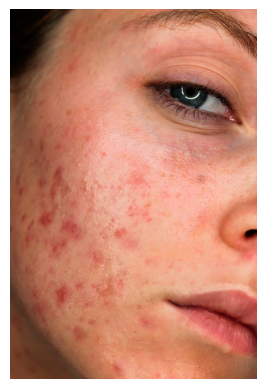

Predicted Disease : Benign_tumors
Confidence : 18.57 %


In [50]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tkinter import Tk
from tkinter.filedialog import askopenfilename

# =========================
# CLASS NAMES
# =========================

class_names = {
    0: 'Acne',
    1: 'Benign_tumors',
    2: 'Infestations_Bites',
    3: 'Moles',
    4: 'Sun_Sunlight_Damage',
    5: 'Unknown_Normal'
}

# =========================
# SELECT IMAGE
# =========================

Tk().withdraw()

file_path = askopenfilename(
    title="Select Skin Image",
    filetypes=[("Image Files", "*.jpg *.png *.jpeg")]
)

# =========================
# READ IMAGE
# =========================

img = cv2.imread(file_path)

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show selected image
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

# =========================
# PREPROCESS IMAGE
# =========================

resized_img = cv2.resize(img_rgb, (224, 224))

normalized_img = resized_img.astype("float32") / 255.0

input_img = np.expand_dims(normalized_img, axis=0)

# =========================
# PREDICTION
# =========================

prediction = model.predict(input_img, verbose=0)

class_index = np.argmax(prediction)

confidence = np.max(prediction)

predicted_disease = class_names[class_index]

# =========================
# RESULT
# =========================

print("Predicted Disease :", predicted_disease)

print("Confidence :", round(confidence * 100, 2), "%")

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tkinter import Tk
from tkinter.filedialog import askopenfilename

# =========================
# CLASS NAMES
# =========================

class_names = {
    0: 'Acne',
    1: 'Benign_tumors',
    2: 'Infestations_Bites',
    3: 'Moles',
    4: 'Sun_Sunlight_Damage',
    5: 'Unknown_Normal'
}

# =========================
# SELECT IMAGE
# =========================

Tk().withdraw()

file_path = askopenfilename(
    title="Select Skin Image",
    filetypes=[("Image Files", "*.jpg *.png *.jpeg")]
)

# =========================
# READ IMAGE
# =========================

img = cv2.imread(file_path)

# Convert BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show image
plt.imshow(img)
plt.axis("off")
plt.show()

# =========================
# IMAGE PREPROCESSING
# =========================

# Resize
img_resized = cv2.resize(img, (224, 224))

# Blur reduction
img_resized = cv2.GaussianBlur(img_resized, (3,3), 0)

# Normalize
img_resized = img_resized.astype("float32") / 255.0

# Expand dimensions
img_input = np.expand_dims(img_resized, axis=0)

# =========================
# PREDICTION
# =========================

prediction = model.predict(img_input, verbose=0)

class_index = np.argmax(prediction)

confidence = np.max(prediction)

predicted_class = class_names[class_index]

# =========================
# RESULT
# =========================

print("\nPredicted Disease :", predicted_class)

print("Confidence :", round(confidence * 100, 2), "%")

# Warning for low confidence
if confidence < 0.60:
    print("\nWarning: Model confidence is low")